# NYC Restaurant Inspections: An Analysis of Critical Health Violations (2016–2026)

-----

## Introduction 
New York City is home to thousands of restaurants inspected annually by the Department of Health and Mental Hygiene (DOHMH). This project analyzes DOHMH inspection records from 2016–2026 to understand how often Critical Violations occur, what drives them, and where NYC's food-safety efforts should focus next.


-----

## Problem Statement

Between 2016 and 2026, inspection records from the New York City Department of Health and Mental Hygiene (DOHMH) show that 52% of restaurant inspections result in at least one Critical Violation — posing a direct risk of foodborne illness to the public. However, it remains unclear which violation types drive this risk most, whether certain cuisines are more prone to critical violations, and whether these risks fluctuate throughout the year. Understanding these patterns is essential for DOHMH to prioritize inspection resources more effectively.

-----

## Objectives:
- What are the 10 most common health violations in NYC restaurants?
- What is the average inspection score for inspections with at least one Critical Violation compared to those without?
- What percentage of restaurant inspections in each NYC borough had at least one Critical Violation?
- How do Critical vs. Non-Critical violation rates differ across the top 10 cuisine types?
- How has the percentage of Critical violations changed year over year (2017–2025)?
- What percentage of violations are classified as Critical across different months of the year?
- How have inspection scores changed between 2022 and 2025 for the top 10 restaurant brands with Critical Violations?

-----

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('DOHMH_New_York_City_Restaurant_Inspection_Results_20260709.csv',low_memory=False)

In [4]:
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50178745,"FORREST SOLUTIONS, LLC",Manhattan,19,WEST 44 STREET,10036.0,2129863600,NaN,01/01/1900,NaN,...,NaN,40.755160,-73.980830,105.0,4.0,9600.0,1034224.0,1.012600e+09,MN17,POINT (-73.98083017402 40.755160414448)
1,50178840,BERRYLICIOUS,Manhattan,1,HERALD SQUARE,10001.0,9174981158,NaN,01/01/1900,NaN,...,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
2,50177020,CALIAM CU LLC,Manhattan,1187,AMSTERDAM AVENUE,10027.0,9172850298,NaN,01/01/1900,NaN,...,NaN,40.808354,-73.959921,109.0,7.0,20701.0,1059499.0,1.019620e+09,MN09,POINT (-73.95992094497 40.808353822955)
3,50188313,Au Bon Pain,Manhattan,625,8 AVENUE,10018.0,8452692402,NaN,01/01/1900,NaN,...,NaN,40.756185,-73.990565,104.0,3.0,11500.0,1083268.0,1.010320e+09,MN15,POINT (-73.990564733785 40.756185423077)
4,50084602,SAN MARCOS CAFE,Bronx,949 A&B,WESTCHESTER AVE,NaN,9176881846,Latin American,04/05/2024,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,2.000000e+00,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 296006 entries, 0 to 296005
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296006 non-null  int64  
 1   DBA                    296004 non-null  str    
 2   BORO                   296006 non-null  str    
 3   BUILDING               295011 non-null  str    
 4   STREET                 295977 non-null  str    
 5   ZIPCODE                292919 non-null  float64
 6   PHONE                  295910 non-null  str    
 7   CUISINE DESCRIPTION    292393 non-null  str    
 8   INSPECTION DATE        296006 non-null  str    
 9   ACTION                 292473 non-null  str    
 10  VIOLATION CODE         289880 non-null  str    
 11  VIOLATION DESCRIPTION  289880 non-null  str    
 12  CRITICAL FLAG          296006 non-null  str    
 13  SCORE                  278886 non-null  float64
 14  GRADE                  146018 non-null  str    

In [6]:
df.isnull().sum()

CAMIS                         0
DBA                           2
BORO                          0
BUILDING                    995
STREET                       29
ZIPCODE                    3087
PHONE                        96
CUISINE DESCRIPTION        3613
INSPECTION DATE               0
ACTION                     3533
VIOLATION CODE             6126
VIOLATION DESCRIPTION      6126
CRITICAL FLAG                 0
SCORE                     17120
GRADE                    149988
GRADE DATE               160313
RECORD DATE                   0
INSPECTION TYPE            3533
Latitude                   1671
Longitude                  1671
Community Board            4720
Council District           4738
Census Tract               4738
BIN                        5944
BBL                        1671
NTA                        4720
Location                   4720
dtype: int64

### Data Handling: 
__Cleaning, transforming, and combining data__

In [7]:
df.duplicated().sum()

np.int64(130)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
#chang the type 
df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'], errors='coerce')

In [10]:
#Filtering data to keep records from 2016 and above
df['INSPECTION_YEAR'] = df['INSPECTION DATE'].dt.year
df = df[df['INSPECTION_YEAR'] >= 2016]

In [11]:
#Filtering data to remove Not Applicable
df = df[(df['CRITICAL FLAG'] != 'Not Applicable')]

In [12]:
df.dropna(subset='VIOLATION CODE',inplace=True)

In [28]:
#Filtering data between 2017-2025
df_grades['YEAR'] = df_grades['INSPECTION DATE'].dt.year
df_grades['MONTH'] = df_grades['INSPECTION DATE'].dt.month
df_filtered = df_grades[(df_grades['YEAR'] > 2016) & (df_grades['YEAR'] < 2026)]

In [17]:
#cleaning the name from '
df['DBA_CLEAN'] = df['DBA'].astype(str).str.upper().str.strip()
df['DBA_CLEAN'] = df['DBA_CLEAN'].str.replace("'", "")

In [18]:
#Filtering data to have Critical
df_critical = df[df['CRITICAL FLAG'] == 'Critical']

In [19]:
#Filtering data to have valid grades
valid_grades = ['A', 'B', 'C']
df_grades = df[df['GRADE'].isin(valid_grades)]

In [20]:
#inspections involve at least one Critical Violation
df_inspections = df.drop_duplicates(subset=['CAMIS', 'INSPECTION DATE'])
critical_pct = (df_inspections['CRITICAL FLAG'] == 'Critical').mean() * 100
critical_pct

np.float64(52.28109082933249)

### Analysis: 
__Answering the objectives through data analysis__



In [25]:
#df['VIOLATION CODE'].value_counts()

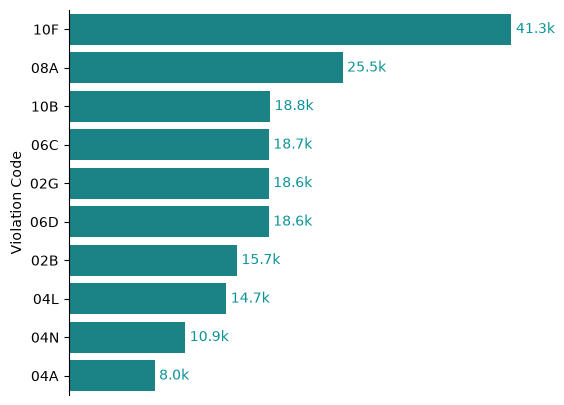

In [38]:
#What are the 10 most common health violations in NYC restaurants?
top_10 = df['VIOLATION CODE'].value_counts().head(10)

plt.figure(figsize=(6, 5))
sns.barplot(x=top_10.values, y=top_10.index, color='#0A9396', legend=False)

for i, v in enumerate(top_10.values):
    plt.text(v + (max(top_10.values) * 0.01), i, f"{v/1000:.1f}k", va='center', color='#0A9396')


plt.xticks([])  
plt.xlabel('')  

plt.ylabel('Violation Code')
sns.despine(bottom=True)  
plt.grid(axis='x', linestyle='--', alpha=0.3)


In [234]:
#critical_counts = df_inspections[df_inspections['CRITICAL FLAG'] == 'Critical'].groupby('BORO').size()
#total_counts = df_inspections.groupby('BORO').size()
#crit_by_boro = ((critical_counts / total_counts) * 100).sort_values(ascending=False)
#crit_by_boro 

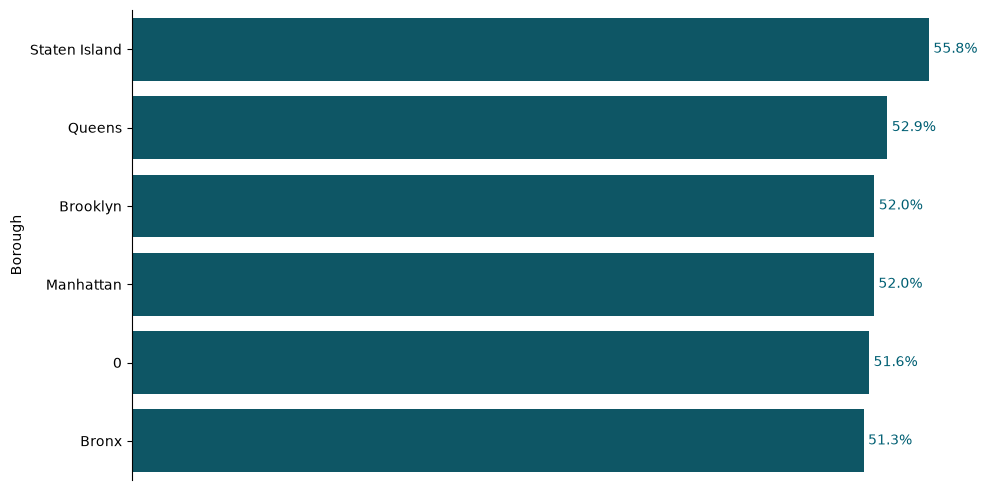

In [39]:
#What percentage of restaurant inspections in each NYC borough had at least one Critical Violation?
df_inspections = df.drop_duplicates(subset=['CAMIS', 'INSPECTION DATE'])
critical_counts = df_inspections[df_inspections['CRITICAL FLAG'] == 'Critical'].groupby('BORO').size()
total_counts = df_inspections.groupby('BORO').size()
crit_by_boro = ((critical_counts / total_counts) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(x=crit_by_boro.values, y=crit_by_boro.index, color='#005F73')
for i, v in enumerate(crit_by_boro.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', color='#005F73')

plt.ylabel('Borough')

plt.xticks([]) 
plt.xlabel('')

sns.despine(bottom=True)  
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

In [194]:
#df_inspections = df.drop_duplicates(subset=['CAMIS', 'INSPECTION DATE'])
#avg_scores = df_inspections.groupby('CRITICAL FLAG')['SCORE'].mean()
#avg_scores 

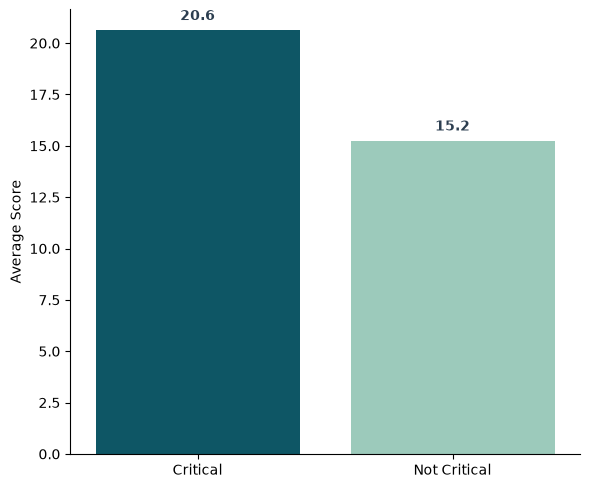

In [40]:
#What is the average inspection score for inspections with at least one Critical Violation compared to those without?


avg_scores = df_inspections.groupby('CRITICAL FLAG')['SCORE'].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=avg_scores.index, y=avg_scores.values, hue=avg_scores.index, palette=['#005F73', '#94D2BD'], legend=False)

for i, v in enumerate(avg_scores.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold', color='#2C3E50')


plt.ylabel('Average Score')
plt.xlabel('')
sns.despine() 
plt.tight_layout()

In [112]:
#top_10_cuisines = df['CUISINE DESCRIPTION'].value_counts().head(10).index
#df[df['CUISINE DESCRIPTION'].isin(top_10_cuisines)].head()

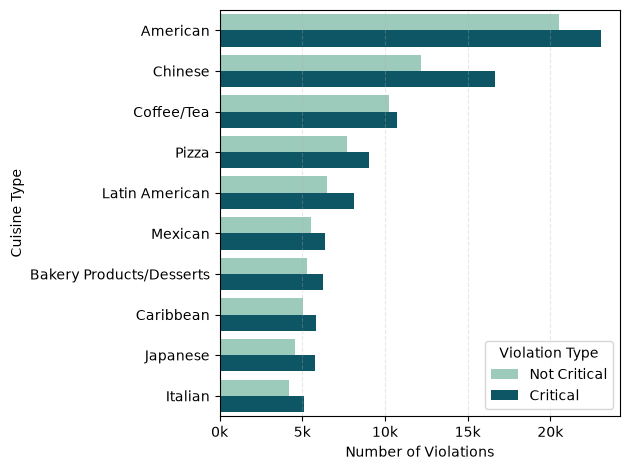

In [43]:
#How do Critical vs. Non-Critical violation rates differ across the top 10 cuisine types?
top_10_cuisines = df['CUISINE DESCRIPTION'].value_counts().head(10).index
df_top_cuisines = df[df['CUISINE DESCRIPTION'].isin(top_10_cuisines)]

sns.countplot(data=df_top_cuisines, y='CUISINE DESCRIPTION', hue='CRITICAL FLAG', order=top_10_cuisines,palette=['#94D2BD','#005F73'])

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))


plt.xlabel('Number of Violations')
plt.ylabel('Cuisine Type')
plt.legend(title='Violation Type')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

In [251]:
#df_grades['MONTH'] = df_grades['INSPECTION DATE'].dt.month
#total_per_month = df_grades.groupby('MONTH').size()
#critical_per_month = df_grades[df_grades['CRITICAL FLAG'] == 'Critical'].groupby('MONTH').size()

#(critical_per_month / total_per_month) * 100

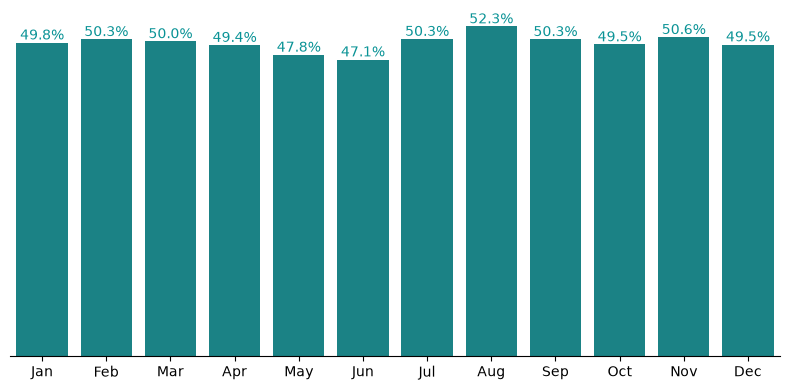

In [44]:
#What percentage of violations are classified as Critical across different months of the year?
df_grades['MONTH'] = df_grades['INSPECTION DATE'].dt.month

total_per_month = df_filtered.groupby('MONTH').size()
critical_per_month = df_filtered[df_filtered['CRITICAL FLAG'] == 'Critical'].groupby('MONTH').size()

critical_percentage = (critical_per_month / total_per_month) * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=critical_percentage.index, y=critical_percentage.values,color='#0A9396' )
for i, v in enumerate(critical_percentage.reindex(range(1, 13)).values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', color='#0A9396')

plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])


plt.yticks([]) 
plt.xlabel('')
plt.ylabel('')

sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3) 
plt.tight_layout()

In [207]:
#df_grades['YEAR'] = df_grades['INSPECTION DATE'].dt.year
#total_per_year = df_grades.groupby('YEAR').size()
#critical_per_year = df_grades[df_grades['CRITICAL FLAG'] == 'Critical'].groupby('YEAR').size()
#critical_percentage_year = (critical_per_year / total_per_year) * 100
#critical_percentage_year

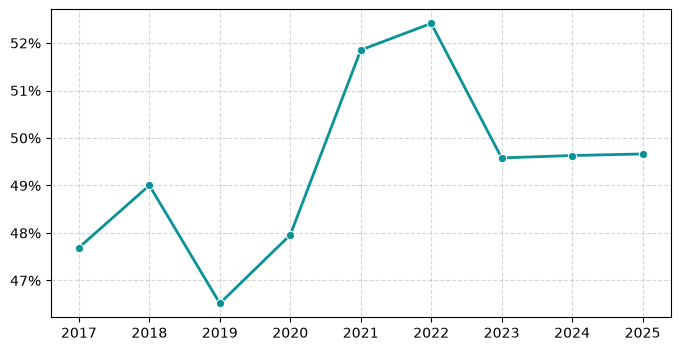

In [45]:
#How has the percentage of Critical violations changed year over year (2016–2026)?
df_grades['YEAR'] = df_grades['INSPECTION DATE'].dt.year
total_per_year = df_filtered.groupby('YEAR').size()
critical_per_year = df_filtered[df_filtered['CRITICAL FLAG'] == 'Critical'].groupby('YEAR').size()
critical_percentage_year = (critical_per_year / total_per_year) * 100

plt.figure(figsize=(8, 4))
sns.lineplot(x=critical_percentage_year.index, y=critical_percentage_year.values, marker='o', color='#0A9396', linewidth=2)

plt.xticks(critical_percentage_year.index)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))

plt.xlabel("")
plt.ylabel("")
plt.grid(True, linestyle='--', alpha=0.5)

In [241]:
#df_critical['YEAR'] = df_critical['INSPECTION DATE'].dt.year
#top_10 = df_critical['DBA_CLEAN'].value_counts().head(10).index

#scores_2022 = df_critical[(df_critical['YEAR'] == 2022) & (df_critical['DBA_CLEAN'].isin(top_10))].groupby('DBA_CLEAN')['SCORE'].mean().reindex(top_10).fillna(0)
#scores_2025 = df_critical[(df_critical['YEAR'] == 2025) & (df_critical['DBA_CLEAN'].isin(top_10))].groupby('DBA_CLEAN')['SCORE'].mean().reindex(top_10).fillna(0)
#print(scores_2022)
#print(scores_2025)

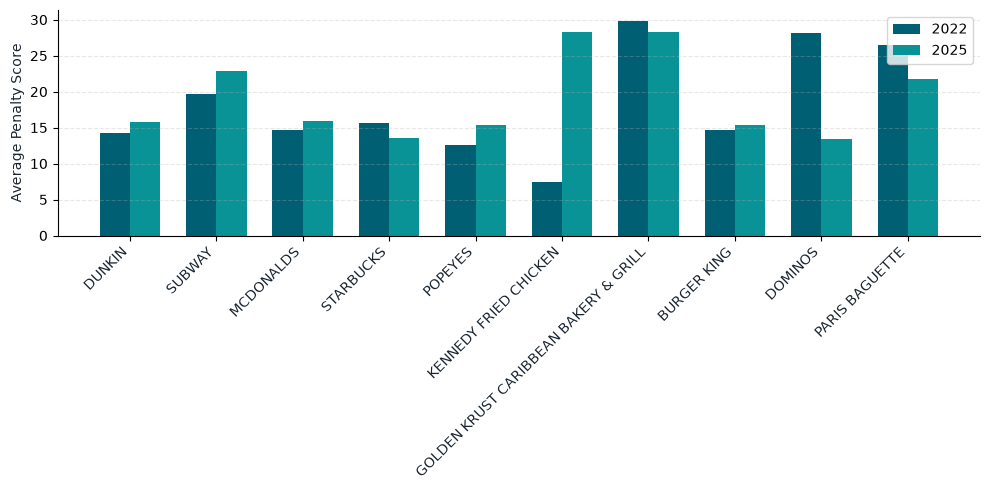

In [49]:
#How have inspection scores changed between 2022 and 2025 for the top 10 restaurant brands with Critical Violations?
df_critical['YEAR'] = df_critical['INSPECTION DATE'].dt.year
top_10 = df_critical['DBA_CLEAN'].value_counts().head(10).index

scores_2022 = df_critical[(df_critical['YEAR'] == 2022) & (df_critical['DBA_CLEAN'].isin(top_10))].groupby('DBA_CLEAN')['SCORE'].mean().reindex(top_10).fillna(0)
scores_2025 = df_critical[(df_critical['YEAR'] == 2025) & (df_critical['DBA_CLEAN'].isin(top_10))].groupby('DBA_CLEAN')['SCORE'].mean().reindex(top_10).fillna(0)

plt.figure(figsize=(10, 5))

x = list(range(len(top_10)))  
width = 0.35  

plt.bar([pos - width/2 for pos in x], scores_2022, width, label='2022', color='#005F73')
plt.bar([pos + width/2 for pos in x], scores_2025, width, label='2025', color='#0A9396')


plt.ylabel("Average Penalty Score", color='#1A2530')

plt.xticks(x, top_10, rotation=45, color='#1A2530', ha='right')

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3) 

plt.legend(loc='upper right')
plt.tight_layout()

---

## Summary
-  Critical Violations are not a small issue — they're the biggest factor behind low hygiene scores, raising penalty scores by over 35%
- Food safety issues aren't limited to one area — all five boroughs fall within a close 51%–56% range for Critical Violations
- Critical violations jumped to their highest point in 2022 (52.4%), then dropped and leveled off around 49.6% in 2023–2025. The data doesn't show why this happened, so it's worth looking into further.
-  Violation rates stay steady all year (47%–52%), suggesting the time of year doesn't have a big effect on kitchen compliance.
-  Large brands like McDonald's and Starbucks kept steady, low-risk scores over time. Smaller chains like Kennedy Fried Chicken saw a sharp drop in compliance, with scores jumping from about 7.5 to 28.3.

---

## Recommendations/Conclusion
- **Focus on the top 3 violation types (10F, 08A, 10B)** they make up the bulk of all violations, so targeted training here goes further than blanket inspections.

- **Treat this as a citywide problem** not a borough problem. Critical violation rates only vary by 4.5 points across boroughs (51.3%–55.8%), so borough-specific fixes won't move the needle much.

- **Keep a closer eye on chains like Kennedy Fried Chickenand Golden Krust** Their scores are high, and some are getting worse — checking one location at a time isn't catching the full problem.

- **Figure out what changed around 2023** that brought violation rates down from a 2022 peak (52.4%) to a stable ~49.6% — and double down on it.